In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [126]:
data = pd.read_csv("data/House price Prediction Dataset.csv")
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [127]:
data.dropna() 

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [128]:
data.isnull().sum() 


Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [129]:
data.duplicated().sum()

np.int64(0)

In [130]:
data.describe(include="all")
data.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

In [131]:
x = data.drop("Price", axis=1)  # feature # input 
y = data["Price"] # target # output
print(x.columns.dtype)

object


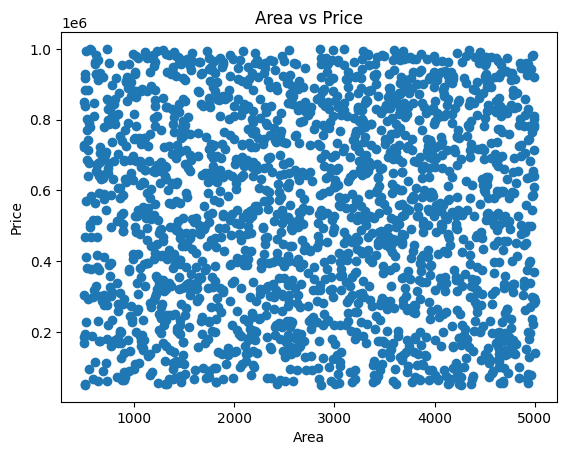

In [132]:

plt.scatter(x["Area"], y)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [145]:
#X = pd.get_dummies(x, columns=["Location","Condition","Garage"], drop_first=True)
categorical_cols = x.select_dtypes(include=["object"]).columns
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)


In [146]:
x_train , x_test, y_train , y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [147]:
print(x_train.dtypes)

Id                   int64
Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors               int64
YearBuilt            int64
Location_Rural        bool
Location_Suburban     bool
Location_Urban        bool
Condition_Fair        bool
Condition_Good        bool
Condition_Poor        bool
Garage_Yes            bool
dtype: object


In [148]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [149]:
from sklearn.linear_model import LinearRegression
housepredmodel = LinearRegression()
housepredmodel.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [150]:
y_pred = housepredmodel.predict(x_test)


In [153]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test,y_pred)
mse =mean_squared_error(y_test,y_pred)
print("MAE: - ",mae)
print("MSE:--" ,mse)


MAE: -  242867.44926338628
MSE:-- 78279764120.86243


In [154]:
COE = pd.DataFrame(
    {
        "Feature":x.columns,
        "Importance": housepredmodel.coef_
    }
).sort_values(by="Importance",ascending=False)

print(COE)

              Feature    Importance
4              Floors  19030.926950
9      Condition_Fair  10605.827753
7   Location_Suburban   4688.807893
5           YearBuilt   4192.578243
11     Condition_Poor   1916.410443
12         Garage_Yes   1107.866928
6      Location_Rural    782.814737
2            Bedrooms     75.999922
1                Area   -629.807550
8      Location_Urban  -5433.722080
10     Condition_Good  -5485.855833
0                  Id  -6892.134735
3           Bathrooms -10906.548221


In [155]:
import pickle
with open ("housepredmodel.pkl","wb") as f:
    pickle.dump(housepredmodel,f)
    